In [1]:
#check metadata for de-indentification
import os
import nibabel as nib

# Path to your extracted BraTS dataset
dataset_path = r"C:\Users\sandj\Downloads\archive (1)\extracted"

# Sensitive metadata keys we should NOT find in a de-identified dataset
sensitive_keys = [
    "patient", "PatientName", "PatientID", "PatientBirthDate",
    "DOB", "Age", "Sex", "InstitutionName", "Hospital",
    "StudyDate", "AcquisitionDate"
]

print("Checking metadata for possible patient information...\n")

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".nii.gz"):
            file_path = os.path.join(root, file)

            try:
                img = nib.load(file_path)
                header = img.header

                # Convert header to string for easy searching
                header_str = str(header)

                found_sensitive = []

                for key in sensitive_keys:
                    if key.lower() in header_str.lower():
                        found_sensitive.append(key)

                if found_sensitive:
                    print(f"⚠️ Possible identifiable metadata found in: {file_path}")
                    print(f"   Keys detected: {found_sensitive}")
                else:
                    print(f"✅ Clean (de-identified): {file_path}")

            except Exception as e:
                print(f"❌ Error reading {file_path}: {e}")

Checking metadata for possible patient information...

✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00495_flair.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00495_seg.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00495_t1.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00495_t1ce.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00495_t2.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00621_flair.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00621_seg.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00621_t1.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\archive (1)\extracted\BraTS2021_00621_t1ce.nii.gz
✅ Clean (de-identified): C:\Users\sandj\Downloads\a

In [4]:
import os
import shutil

# -------------------- Dataset Path --------------------
dataset_path = r"C:\Users\sandj\Downloads\archive (1)\extracted"
modalities = ["flair", "t1", "t1ce", "t2", "seg"]

# -------------------- Counters --------------------
complete_patients = 0
incomplete_patients = 0
extra_folders = []

print("🔍 Checking patient folders...\n")

# -------------------- Check each folder --------------------
for patient_folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, patient_folder)
    if os.path.isdir(folder_path):
        files_in_folder = os.listdir(folder_path)
        # Count how many required modalities exist in this folder
        found_modalities = sum(any(mod in f for f in files_in_folder) for mod in modalities)
        
        if found_modalities == len(modalities):
            complete_patients += 1
            print(f"✅ {patient_folder}: All files present")
        else:
            incomplete_patients += 1
            extra_folders.append(patient_folder)
            missing = [mod for mod in modalities if not any(mod in f for f in files_in_folder)]
            print(f"❌ {patient_folder}: Missing files → {missing}")

# -------------------- Summary before deletion --------------------
print("\n📌 Dataset Summary (Before Removal)")
print(f"Total patient folders: {len(os.listdir(dataset_path))}")
print(f"Complete patients (all 5 files present): {complete_patients}")
print(f"Incomplete/non-patient folders: {incomplete_patients}")
print(f"Folders to remove: {len(extra_folders)}")
print(extra_folders)

# -------------------- Automatically remove extra folders --------------------
for folder in extra_folders:
    folder_path = os.path.join(dataset_path, folder)
    print(f"🗑 Removing folder: {folder_path}")
    shutil.rmtree(folder_path)

# -------------------- Summary after deletion --------------------
remaining_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print("\n✅ All non-patient folders removed successfully!")
print(f"Remaining valid patient folders: {len(remaining_folders)}")





🔍 Checking patient folders...

✅ BraTS2021_00000: All files present
✅ BraTS2021_00002: All files present
✅ BraTS2021_00003: All files present
✅ BraTS2021_00005: All files present
✅ BraTS2021_00006: All files present
✅ BraTS2021_00008: All files present
✅ BraTS2021_00009: All files present
✅ BraTS2021_00011: All files present
✅ BraTS2021_00012: All files present
✅ BraTS2021_00014: All files present
✅ BraTS2021_00016: All files present
✅ BraTS2021_00017: All files present
✅ BraTS2021_00018: All files present
✅ BraTS2021_00019: All files present
✅ BraTS2021_00020: All files present
✅ BraTS2021_00021: All files present
✅ BraTS2021_00022: All files present
✅ BraTS2021_00024: All files present
✅ BraTS2021_00025: All files present
✅ BraTS2021_00026: All files present
✅ BraTS2021_00028: All files present
✅ BraTS2021_00030: All files present
✅ BraTS2021_00031: All files present
✅ BraTS2021_00032: All files present
✅ BraTS2021_00033: All files present
✅ BraTS2021_00035: All files present
✅ BraTS

In [5]:
import os

dataset_path = r"C:\Users\sandj\Downloads\archive (1)\extracted"
modalities = ["flair", "t1", "t1ce", "t2", "seg"]

valid_patients = []
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        files_in_folder = os.listdir(folder_path)
        if all(any(mod in f for f in files_in_folder) for mod in modalities):
            valid_patients.append(folder)

print(f"✅ Total valid patients: {len(valid_patients)}")
print(f"Example patients: {valid_patients[:5]}")


✅ Total valid patients: 1251
Example patients: ['BraTS2021_00000', 'BraTS2021_00002', 'BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006']


In [1]:
import os
import numpy as np
import nibabel as nib

# ----------------------- Config -----------------------
dataset_path = r"C:\Users\sandj\Downloads\archive (1)\extracted"
save_path = r"C:\Users\sandj\Downloads\processed_brats"
os.makedirs(save_path, exist_ok=True)

modalities = ["flair", "t1", "t1ce", "t2"]

# -------------------- Helper Functions --------------------
def load_patient_slicewise(patient_path):
    """
    Load MRI modalities and segmentation mask for one patient slice by slice.
    Returns:
        imgs: np.array of shape (4, H, W, D), dtype float32
        mask: np.array of shape (H, W, D), dtype uint8
    """
    imgs = []
    for m in modalities:
        file = [f for f in os.listdir(patient_path) if m in f][0]
        img_obj = nib.load(os.path.join(patient_path, file)).dataobj  # memory-mapped
        H, W, D = img_obj.shape
        img_array = np.zeros((H, W, D), dtype=np.float32)

        # Load slice by slice
        for z in range(D):
            img_array[:, :, z] = img_obj[:, :, z].astype(np.float32)
        
        # Normalize per modality
        img_array = (img_array - np.mean(img_array)) / (np.std(img_array) + 1e-8)
        imgs.append(img_array)

    # Load segmentation mask (usually smaller values, can fit in memory)
    seg_file = [f for f in os.listdir(patient_path) if "seg" in f][0]
    mask_obj = nib.load(os.path.join(patient_path, seg_file)).dataobj
    mask = np.zeros(mask_obj.shape, dtype=np.uint8)
    for z in range(mask_obj.shape[2]):
        mask[:, :, z] = mask_obj[:, :, z].astype(np.uint8)

    return np.array(imgs, dtype=np.float32), mask

# -------------------- Main Loop --------------------
patient_ids = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(f"Found {len(patient_ids)} patients.")

for pid in patient_ids:
    patient_path = os.path.join(dataset_path, pid)
    imgs, mask = load_patient_slicewise(patient_path)

    # Save individually
    np.save(os.path.join(save_path, f"{pid}_images.npy"), imgs)
    np.save(os.path.join(save_path, f"{pid}_mask.npy"), mask)

    print(f"Saved {pid} | Images shape: {imgs.shape}, Mask shape: {mask.shape}")






Found 1251 patients.
Saved BraTS2021_00000 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00002 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00003 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00005 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00006 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00008 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00009 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00011 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00012 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00014 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00016 | Images shape: (4, 240, 240, 155), Mask shape: (240, 240, 155)
Saved BraTS2021_00017 | Images sh

In [5]:
!pip install numpy matplotlib opencv-python scikit-learn scipy






Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 2.6 MB/s eta 0:00:15
   - -------------------------------------- 1.0/39.0 MB 2.5 MB/s eta 0:00:15
   - -------------------------------------- 1.8/39.0 MB 3.0 MB/s eta 0:00:13
   -- ------------------------------------- 2.4/39.0 MB 3.0 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/39.0 MB 3.2 MB/s eta 0:00:12
   ---- ----------------------------------- 3.9/39.0 MB 3.2 MB/s eta 0:00:11
   ---- ----------------------------------- 4.7/39.0 MB 3.2 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/39.0 MB 3.2 MB/s eta 0:00:11
   ------ --------------------------------- 6.3/39.0 MB 3.3 MB/s eta 0:00:10
   ------- -------------------------------- 7.1/39.0 MB 3.4 MB/s eta 0:00:10
   -------- 

In [7]:
!pip install albumentations



Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 1.3 MB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 1.3 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.0 MB 1.5 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.0 MB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 1.6/2.0 MB 1.3 MB/s eta 0:00:01
   ------------------------------------ --- 1.8/2.0 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 1.3 MB/s  0:00:01

   ---------- ----------------------------- 2/8 [stringzilla]
   ---------- ----------------------------- 2/8 [stringzilla]
   ---------- ----------------------------- 2/8 [stringzilla]
   --------------- ------------------------ 3/8 [pydantic-core]
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [8]:
# ----------------------- Config & Setup -----------------------
import os
import numpy as np
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2  # for resizing
import albumentations as A  # for augmentation

# Only this path is needed now
save_path = r"C:\Users\sandj\Downloads\processed_brats"       # Already normalized .npy files

# This is where final preprocessed dataset will go
preprocessed_path = r"C:\Users\sandj\Downloads\preprocessed_final"
os.makedirs(preprocessed_path, exist_ok=True)

# Preprocessing parameters
target_size = (128, 128)  # Resize HxW
num_classes = 4           # Number of mask classes including background


In [13]:
def load_patient_npy(patient_id):
    """
    Load already normalized .npy images and mask
    """
    img_file = os.path.join(save_path, f"{patient_id}_images.npy")
    mask_file = os.path.join(save_path, f"{patient_id}_mask.npy")

    imgs = np.load(img_file)   # shape: (4, H, W, D)
    mask = np.load(mask_file)  # shape: (H, W, D)

    return imgs, mask


In [14]:
def resize_slices(imgs, mask, target_size=(128,128), num_classes=4):
    """
    Resize all slices to target_size and convert mask to one-hot format.
    imgs: (C, H, W, D)
    mask: (H, W, D)
    """
    C, H, W, D = imgs.shape

    resized_imgs = np.zeros((C, target_size[0], target_size[1], D), dtype=np.float32)
    resized_mask = np.zeros((num_classes, target_size[0], target_size[1], D), dtype=np.uint8)

    for z in range(D):
        for c in range(C):
            resized_imgs[c, :, :, z] = cv2.resize(
                imgs[c, :, :, z], target_size, interpolation=cv2.INTER_LINEAR
            )

        for cls in range(num_classes):
            resized_mask[cls, :, :, z] = cv2.resize(
                (mask[:, :, z] == cls).astype(np.uint8),
                target_size,
                interpolation=cv2.INTER_NEAREST
            )

    return resized_imgs, resized_mask



In [15]:
# ---- Test the functions ----

# Pick any one patient folder name
test_patient = os.listdir(save_path)[0].replace("_images.npy", "").replace("_mask.npy", "")

imgs, mask = load_patient_npy(test_patient)

print("Original imgs shape:", imgs.shape)
print("Original mask shape:", mask.shape)

resized_imgs, resized_mask = resize_slices(imgs, mask)

print("\nResized imgs shape:", resized_imgs.shape)
print("Resized mask shape:", resized_mask.shape)


Original imgs shape: (4, 240, 240, 155)
Original mask shape: (240, 240, 155)

Resized imgs shape: (4, 128, 128, 155)
Resized mask shape: (4, 128, 128, 155)


In [17]:
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

# -------------------- Augmentation --------------------
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3)  # removed alpha_affine
], additional_targets={"mask": "mask"})

def augment_slices(imgs, mask):
    """
    Apply augmentation slice-by-slice.
    imgs: numpy array of shape (C, H, W, D)
    mask: numpy array of shape (C, H, W, D)
    Returns augmented images and mask with same shape.
    """
    print(f"Original imgs shape: {imgs.shape}, mask shape: {mask.shape}")
    
    C, H, W, D = imgs.shape
    aug_imgs = np.zeros_like(imgs)
    aug_mask = np.zeros_like(mask)

    for z in range(D):
        # Convert from (C,H,W) -> (H,W,C) for albumentations
        img_slice = np.transpose(imgs[:,:,:,z], (1,2,0))
        mask_slice = np.transpose(mask[:,:,:,z], (1,2,0))

        augmented = transform(image=img_slice, mask=mask_slice)

        # Convert back to (C,H,W)
        aug_imgs[:,:,:,z] = np.transpose(augmented['image'], (2,0,1))
        aug_mask[:,:,:,z] = np.transpose(augmented['mask'], (2,0,1))
    
    print(f"Augmented imgs shape: {aug_imgs.shape}, Augmented mask shape: {aug_mask.shape}")
    return aug_imgs, aug_mask

# -------------------- Test --------------------
if __name__ == "__main__":
    # Dummy resized data: 4 channels, 128x128, 155 slices
    imgs = np.random.rand(4,128,128,155)
    mask = np.random.randint(0,2,(4,128,128,155))

    aug_imgs, aug_mask = augment_slices(imgs, mask)



Original imgs shape: (4, 128, 128, 155), mask shape: (4, 128, 128, 155)
Augmented imgs shape: (4, 128, 128, 155), Augmented mask shape: (4, 128, 128, 155)


In [18]:
patient_ids = [f.replace("_images.npy","") for f in os.listdir(save_path) if "images.npy" in f]

train_ids, test_ids = train_test_split(patient_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.1, random_state=42)

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")


Train: 900, Val: 100, Test: 251


In [37]:
import os
import numpy as np

# -------------------- Space-efficient Preprocessing Loop --------------------
for split, ids in zip(["train", "val", "test"], [train_ids, val_ids, test_ids]):

    split_path = os.path.join(preprocessed_path, split)
    os.makedirs(split_path, exist_ok=True)

    for pid in ids:

        # 1. Load patient
        imgs, mask = load_patient_npy(pid)    # imgs: (4,H,W,D), mask: (4,H,W,D)

        # 2. Resize slices to target shape
        imgs, mask = resize_slices(
            imgs,
            mask,
            target_size=target_size,
            num_classes=num_classes
        )

        # 3. Convert to float16 (reduce storage by 50%)
        imgs = imgs.astype(np.float16)
        mask = mask.astype(np.float16)

        # 4. Save in compressed .npz (very small)
        save_file = os.path.join(split_path, f"{pid}.npz")
        np.savez_compressed(save_file, images=imgs, mask=mask)

        print(f"{split} | Saved {pid} | File size: {os.path.getsize(save_file)/1e6:.2f} MB")



train | Saved BraTS2021_00157 | File size: 3.08 MB
train | Saved BraTS2021_01327 | File size: 2.97 MB
train | Saved BraTS2021_01145 | File size: 2.50 MB
train | Saved BraTS2021_01624 | File size: 2.64 MB
train | Saved BraTS2021_01555 | File size: 2.23 MB
train | Saved BraTS2021_01615 | File size: 2.49 MB
train | Saved BraTS2021_01177 | File size: 2.67 MB
train | Saved BraTS2021_01256 | File size: 2.68 MB
train | Saved BraTS2021_00757 | File size: 3.13 MB
train | Saved BraTS2021_01480 | File size: 2.41 MB
train | Saved BraTS2021_01106 | File size: 3.55 MB
train | Saved BraTS2021_01024 | File size: 2.77 MB
train | Saved BraTS2021_00495 | File size: 2.95 MB
train | Saved BraTS2021_00207 | File size: 2.94 MB
train | Saved BraTS2021_01380 | File size: 2.96 MB
train | Saved BraTS2021_01002 | File size: 2.66 MB
train | Saved BraTS2021_01311 | File size: 2.79 MB
train | Saved BraTS2021_00650 | File size: 2.94 MB
train | Saved BraTS2021_01640 | File size: 2.84 MB
train | Saved BraTS2021_00630 |

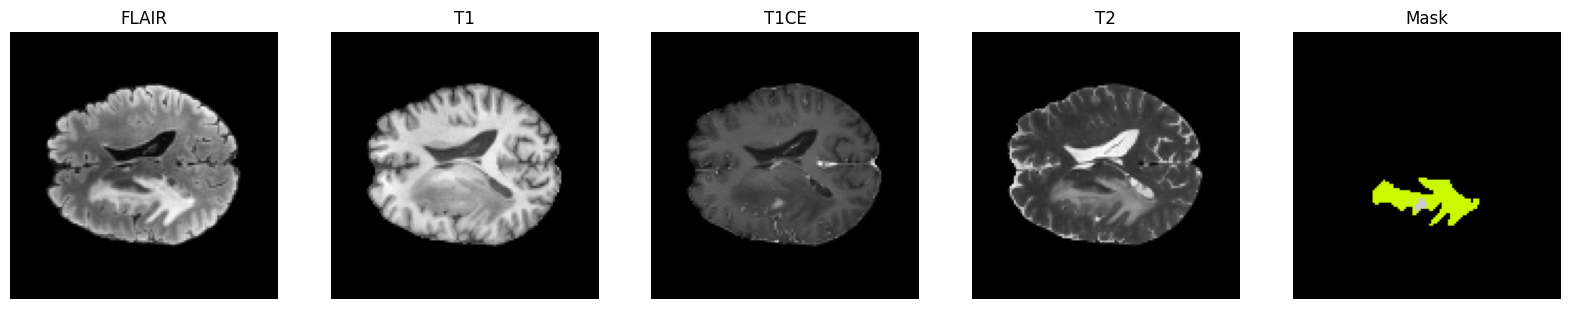

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random

def visualize(patient_id, split="train"):
    # Load the .npz file
    file_path = os.path.join(preprocessed_path, split, f"{patient_id}.npz")
    data = np.load(file_path)
    imgs = data["images"]  # shape: (C, H, W, D)
    mask = data["mask"]    # shape: (num_classes, H, W, D)

    mid = imgs.shape[3] // 2  # middle slice along depth
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))
    names = ["FLAIR", "T1", "T1CE", "T2", "Mask"]

    # Display modalities
    for i in range(4):
        ax[i].imshow(imgs[i, :, :, mid], cmap="gray")
        ax[i].set_title(names[i])
        ax[i].axis("off")

    # Display mask
    ax[4].imshow(np.argmax(mask[:, :, :, mid], axis=0), cmap="nipy_spectral")
    ax[4].set_title("Mask")
    ax[4].axis("off")

    plt.show()

# Example: visualize a random patient from train
visualize(random.choice(train_ids), split="train")



In [25]:
# CPU-only version
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu



Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu


In [39]:
import torch
from torch.utils.data import Dataset
import numpy as np
import os

class BraTSDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted([f for f in os.listdir(folder) if f.endswith(".npz")])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(os.path.join(self.folder, self.files[idx]))
        imgs = data["images"]      # (4, H, W, D)
        mask = data["mask"]        # (4, H, W, D)

        imgs = torch.tensor(imgs, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return imgs, mask





In [41]:
from torch.utils.data import DataLoader

train_folder = r"C:\Users\sandj\Downloads\preprocessed_final\train"
val_folder   = r"C:\Users\sandj\Downloads\preprocessed_final\val"

train_dataset = BraTSDataset(train_folder)
val_dataset   = BraTSDataset(val_folder)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)

for X, y in train_loader:
    print(f"Images -> batch:{X.shape[0]}, channels:{X.shape[1]}, "
      f"height:{X.shape[2]}, width:{X.shape[3]}, depth:{X.shape[4]}")

    print(f"Mask -> batch:{y.shape[0]}, classes:{y.shape[1]}, "
      f"height:{y.shape[2]}, width:{y.shape[3]}, depth:{y.shape[4]}")

    break



Images -> batch:1, channels:4, height:128, width:128, depth:155
Mask -> batch:1, classes:4, height:128, width:128, depth:155
